In [3]:
import pandas as pd

In [4]:
# assign data sets as easy-to-use variables (crash_data and heat_data)
crash_data = pd.read_csv('../data/Motor_Vehicle_Collisions_-_Crashes_20260415.csv')
heat_data = pd.read_csv('../data/NOW Monthly NYC Weather Data.csv')

/var/folders/vp/4774jgz130lg1phx71wsz7lh0000gn/T/ipykernel_89552/1335946872.py:2: DtypeWarning: Columns (0: BOROUGH) have mixed types. Specify dtype option on import or set low_memory=False.
  crash_data = pd.read_csv('../data/Motor_Vehicle_Collisions_-_Crashes_20260415.csv')


In [5]:
crash_data.dtypes #check out value types under each column

CRASH DATE                           str
CRASH TIME                           str
BOROUGH                              str
ZIP CODE                         float64
LATITUDE                         float64
LONGITUDE                        float64
LOCATION                             str
ON STREET NAME                       str
CROSS STREET NAME                    str
OFF STREET NAME                      str
NUMBER OF PERSONS INJURED        float64
NUMBER OF PERSONS KILLED           int64
NUMBER OF PEDESTRIANS INJURED      int64
NUMBER OF PEDESTRIANS KILLED       int64
NUMBER OF CYCLIST INJURED          int64
NUMBER OF CYCLIST KILLED           int64
NUMBER OF MOTORIST INJURED         int64
NUMBER OF MOTORIST KILLED          int64
CONTRIBUTING FACTOR VEHICLE 1        str
CONTRIBUTING FACTOR VEHICLE 2        str
CONTRIBUTING FACTOR VEHICLE 3        str
CONTRIBUTING FACTOR VEHICLE 4        str
CONTRIBUTING FACTOR VEHICLE 5        str
COLLISION_ID                       int64
VEHICLE TYPE COD

In [6]:
crash_data = pd.read_csv('../data/Motor_Vehicle_Collisions_-_Crashes_20260415.csv',
    parse_dates = ['CRASH DATE'],
    dtype = {'NUMBER OF PERSONS INJURED': 'Int64'}) # assign CRASH DATE as correct datetime format, and convert PERSONS INJURED to whole numbers

/var/folders/vp/4774jgz130lg1phx71wsz7lh0000gn/T/ipykernel_89552/627144932.py:1: DtypeWarning: Columns (0: BOROUGH) have mixed types. Specify dtype option on import or set low_memory=False.
  crash_data = pd.read_csv('../data/Motor_Vehicle_Collisions_-_Crashes_20260415.csv',


In [7]:
crash_data.dtypes # make sure the change was correct - looks like it was!

CRASH DATE                       datetime64[us]
CRASH TIME                                  str
BOROUGH                                     str
ZIP CODE                                float64
LATITUDE                                float64
LONGITUDE                               float64
LOCATION                                    str
ON STREET NAME                              str
CROSS STREET NAME                           str
OFF STREET NAME                             str
NUMBER OF PERSONS INJURED                 Int64
NUMBER OF PERSONS KILLED                  int64
NUMBER OF PEDESTRIANS INJURED             int64
NUMBER OF PEDESTRIANS KILLED              int64
NUMBER OF CYCLIST INJURED                 int64
NUMBER OF CYCLIST KILLED                  int64
NUMBER OF MOTORIST INJURED                int64
NUMBER OF MOTORIST KILLED                 int64
CONTRIBUTING FACTOR VEHICLE 1               str
CONTRIBUTING FACTOR VEHICLE 2               str
CONTRIBUTING FACTOR VEHICLE 3           

In [8]:
crash_data.head() #check out the columns really quickly to make sure everything looks right

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,...,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
0,2021-04-11,22:50,STATEN ISLAND,10307.0,40.509865,-74.244150,"(40.509865, -74.24415)",NaN,NaN,7430 AMBOY ROAD,...,Unspecified,Unspecified,NaN,NaN,4408640,Sedan,Station Wagon/Sport Utility Vehicle,Station Wagon/Sport Utility Vehicle,NaN,NaN
1,2023-09-22,22:56,STATEN ISLAND,10304.0,40.610664,-74.093575,"(40.610664, -74.093575)",NaN,NaN,755 NARROWS ROAD NORTH,...,Unspecified,NaN,NaN,NaN,4664536,Sedan,Sedan,NaN,NaN,NaN
2,2021-06-28,11:45,STATEN ISLAND,10304.0,40.624115,-74.081140,"(40.624115, -74.08114)",NaN,NaN,191 BROAD STREET,...,Unspecified,NaN,NaN,NaN,4433908,Sedan,Pick-up Truck,NaN,NaN,NaN
3,2024-12-18,6:34,STATEN ISLAND,10306.0,40.559982,-74.119380,"(40.559982, -74.11938)",MEDINA ST,GUYON AVE,NaN,...,Unspecified,NaN,NaN,NaN,4779621,Sedan,Pick-up Truck,NaN,NaN,NaN
4,2021-07-07,13:05,STATEN ISLAND,10305.0,40.586414,-74.092186,"(40.586414, -74.092186)",NaN,NaN,1740 HYLAN BOULEVARD,...,NaN,NaN,NaN,NaN,4434916,Sedan,NaN,NaN,NaN,NaN


In [9]:
crash_data['NUMBER OF PEDESTRIANS INJURED'] # see what pedestrian injuries column looks like

0         0
1         0
2         0
3         0
4         0
         ..
487644    0
487645    0
487646    0
487647    0
487648    0
Name: NUMBER OF PEDESTRIANS INJURED, Length: 487649, dtype: int64

In [10]:
pedestrian_injuries = crash_data[(crash_data['NUMBER OF PEDESTRIANS INJURED'] > 0) | (crash_data['NUMBER OF PEDESTRIANS KILLED'] > 0)] # create a new dataframe with only crashes that had at least one pedestrian injury or (|) death

In [11]:
pedestrian_injuries['NUMBER OF PEDESTRIANS INJURED'] #make sure the new dataframe looks right

10        1
23        1
28        1
34        1
42        1
         ..
487509    1
487543    1
487554    1
487636    1
487642    1
Name: NUMBER OF PEDESTRIANS INJURED, Length: 43017, dtype: int64

In [12]:
len(pedestrian_injuries) # see how many crashes had at least one pedestrian injury or death between 2021 and 2026

43017

In [13]:
filtered_crash_data = pedestrian_injuries[['CRASH DATE', 'BOROUGH', 'ZIP CODE', 'LOCATION', 'NUMBER OF PEDESTRIANS INJURED', 'NUMBER OF PEDESTRIANS KILLED', 'CONTRIBUTING FACTOR VEHICLE 1', 'CONTRIBUTING FACTOR VEHICLE 2', 'COLLISION_ID', 'VEHICLE TYPE CODE 1', 'VEHICLE TYPE CODE 2']]
# new filtered dataframe

In [14]:
len(filtered_crash_data) # make sure the row counts are the same as pedestrian_injuries dataframe

43017

In [15]:
filtered_crash_data.head() # take a look at the new filtered dataframe with less columns

,CRASH DATE,BOROUGH,ZIP CODE,LOCATION,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,CONTRIBUTING FACTOR VEHICLE 1,CONTRIBUTING FACTOR VEHICLE 2,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2
10,2024-01-17,STATEN ISLAND,10308.0,"(40.55707, -74.15403)",1,0,Driver Inattention/Distraction,NaN,4695786,Sedan,NaN
23,2022-03-10,STATEN ISLAND,10312.0,"(40.546253, -74.158875)",1,0,Backing Unsafely,Unspecified,4510477,Pick-up Truck,Sedan
28,2022-03-10,STATEN ISLAND,10306.0,"(40.587074, -74.10393)",1,0,Unspecified,NaN,4510485,Station Wagon/Sport Utility Vehicle,NaN
34,2024-09-26,STATEN ISLAND,10301.0,"(40.63197, -74.075966)",1,0,Driver Inattention/Distraction,NaN,4760367,Station Wagon/Sport Utility Vehicle,NaN
42,2023-09-15,STATEN ISLAND,10304.0,"(40.623253, -74.08383)",1,0,Unspecified,NaN,4662502,Pick-up Truck,NaN


In [29]:
filtered_crash_data['YR-M'] = filtered_crash_data['CRASH DATE'].dt.to_period('M') # turns days into YEAR-MONTH format


In [30]:
filtered_crash_data.head()

,CRASH DATE,BOROUGH,ZIP CODE,LOCATION,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,CONTRIBUTING FACTOR VEHICLE 1,CONTRIBUTING FACTOR VEHICLE 2,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,YR-M
10,2024-01-17,STATEN ISLAND,10308.0,"(40.55707, -74.15403)",1,0,Driver Inattention/Distraction,NaN,4695786,Sedan,NaN,2024-01
23,2022-03-10,STATEN ISLAND,10312.0,"(40.546253, -74.158875)",1,0,Backing Unsafely,Unspecified,4510477,Pick-up Truck,Sedan,2022-03
28,2022-03-10,STATEN ISLAND,10306.0,"(40.587074, -74.10393)",1,0,Unspecified,NaN,4510485,Station Wagon/Sport Utility Vehicle,NaN,2022-03
34,2024-09-26,STATEN ISLAND,10301.0,"(40.63197, -74.075966)",1,0,Driver Inattention/Distraction,NaN,4760367,Station Wagon/Sport Utility Vehicle,NaN,2024-09
42,2023-09-15,STATEN ISLAND,10304.0,"(40.623253, -74.08383)",1,0,Unspecified,NaN,4662502,Pick-up Truck,NaN,2023-09


In [31]:
# Group by month and aggregate injury counts
monthly_crash_data = filtered_crash_data.groupby('YR-M').agg({
    'NUMBER OF PEDESTRIANS INJURED': ['sum', 'mean'],
    'NUMBER OF PEDESTRIANS KILLED': ['sum', 'mean'],
}).reset_index()

# Flatten column names
monthly_crash_data.columns = ['YR-M', 'Ped_Injuries_Sum', 'Ped_Injuries_Avg', 'Ped_Deaths_Sum', 'Ped_Deaths_Avg']

In [32]:
monthly_crash_data.head()

,YR-M,Ped_Injuries_Sum,Ped_Injuries_Avg,Ped_Deaths_Sum,Ped_Deaths_Avg
0,2021-01,509,1.026210,9,0.018145
1,2021-02,390,1.010363,9,0.023316
2,2021-03,529,1.013410,11,0.021073
3,2021-04,542,1.005566,15,0.027829
4,2021-05,642,1.009434,17,0.026730


In [33]:
# Most common contributing factor per month
top_factor = filtered_crash_data.groupby('YR-M')['CONTRIBUTING FACTOR VEHICLE 1'].apply(lambda x: x.mode()[0] if len(x.mode()) > 0 else None)

# Most common vehicle code per month
top_vehicle = filtered_crash_data.groupby('YR-M')['VEHICLE TYPE CODE 1'].apply(lambda x: x.mode()[0] if len(x.mode()) > 0 else None)

# Combine together
monthly_crash_data['Top_Contributing_Factor'] = top_factor.values
monthly_crash_data['Top_Vehicle_Code'] = top_vehicle.values

In [34]:
monthly_crash_data.tail() #make sure it looks right!

,YR-M,Ped_Injuries_Sum,Ped_Injuries_Avg,Ped_Deaths_Sum,Ped_Deaths_Avg,Top_Contributing_Factor,Top_Vehicle_Code
55,2025-08,555,1.007260,12,0.021779,Unspecified,Sedan
56,2025-09,789,1.032723,8,0.010471,Unspecified,Sedan
57,2025-10,907,1.029512,14,0.015891,Driver Inattention/Distraction,Sedan
58,2025-11,874,1.036773,6,0.007117,Driver Inattention/Distraction,Sedan
59,2025-12,971,1.024262,13,0.013713,Failure to Yield Right-of-Way,Sedan


In [35]:
heat_data.head() # now we bring in the other data set to compare monthly heat to monthly pedestrian injuries and deaths from vehicle collisions

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Annual_Avg
0,2021,44.0,46.5,67,68.5,78.0,86.5,85.0,86.0,78.0,71.0,59.0,58.0,86.5
1,2022,53.0,58.5,62,68.0,80.5,81.5,87.0,87.5,80.5,67.0,70.5,56.5,87.5
2,2023,57.5,63.0,55,80.5,76.0,78.5,83.5,80.5,85.0,74.5,59.5,55.5,85.0
3,2024,52.5,53.5,62,75.0,76.0,85.0,86.0,85.5,77.0,71.5,72.0,55.0,86.0
4,2025,45.0,50.0,62,69.5,74.0,90.0,87.5,82.0,76.0,74.0,59.5,45.0,90.0


In [36]:
heat_data_fixed = heat_data.melt(id_vars=['Year'],
    value_vars=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    var_name='Month',
    value_name='Temperature')
# this turns heat_data, which is a table, into the long format we need it to be so we can compare

In [37]:
heat_data_fixed.head()

,Year,Month,Temperature
0,2021,Jan,44.0
1,2022,Jan,53.0
2,2023,Jan,57.5
3,2024,Jan,52.5
4,2025,Jan,45.0


In [38]:
heat_data_fixed.tail()

,Year,Month,Temperature
55,2021,Dec,58.0
56,2022,Dec,56.5
57,2023,Dec,55.5
58,2024,Dec,55.0
59,2025,Dec,45.0


In [39]:
# Map month names to numbers
month_numbers = {'Jan': '01', 'Feb': '02', 'Mar': '03', 'Apr': '04', 'May': '05', 'Jun': '06',
             'Jul': '07', 'Aug': '08', 'Sep': '09', 'Oct': '10', 'Nov': '11', 'Dec': '12'}
heat_data_fixed['Month_Num'] = heat_data_fixed['Month'].map(month_numbers)
# this basically turns Month Names in month numbers

# Create Year-Month in format to match monthly_crash_data
heat_data_fixed['YearMonth'] = heat_data_fixed['Year'].astype(str) + '-' + heat_data_fixed['Month_Num']
# this combines the month numbers and year values into the YR-M format we are using on the pedestrian injury data

In [40]:
heat_data_fixed.head() # did it work?

,Year,Month,Temperature,Month_Num,YearMonth
0,2021,Jan,44.0,01,2021-01
1,2022,Jan,53.0,01,2022-01
2,2023,Jan,57.5,01,2023-01
3,2024,Jan,52.5,01,2024-01
4,2025,Jan,45.0,01,2025-01


In [41]:
heat_data_fixed = heat_data_fixed[['Temperature', 'YearMonth']] # we don't need the extra columns, just the YR-M and the avg temperature

In [42]:
heat_data_fixed.head() # making sure it looks right

,Temperature,YearMonth
0,44.0,2021-01
1,53.0,2022-01
2,57.5,2023-01
3,52.5,2024-01
4,45.0,2025-01


In [43]:
heat_data_fixed.dtypes

Temperature    float64
YearMonth          str
dtype: object

In [44]:
monthly_crash_data.dtypes

YR-M                       period[M]
Ped_Injuries_Sum               int64
Ped_Injuries_Avg             float64
Ped_Deaths_Sum                 int64
Ped_Deaths_Avg               float64
Top_Contributing_Factor          str
Top_Vehicle_Code                 str
dtype: object

In [45]:
monthly_crash_data = monthly_crash_data.astype({'YR-M': 'str'}) # change the YR-M column into a str to match the heat_data_fixed YRM column

In [46]:
monthly_crash_data.dtypes

YR-M                           str
Ped_Injuries_Sum             int64
Ped_Injuries_Avg           float64
Ped_Deaths_Sum               int64
Ped_Deaths_Avg             float64
Top_Contributing_Factor        str
Top_Vehicle_Code               str
dtype: object

In [47]:
monthly_crash_data = monthly_crash_data.rename(columns={'YR-M': 'YearMonth'}) # rename the YR-M column to YearMonth so we can merge it better

In [48]:
monthly_crash_data.head() # there we go

,YearMonth,Ped_Injuries_Sum,Ped_Injuries_Avg,Ped_Deaths_Sum,Ped_Deaths_Avg,Top_Contributing_Factor,Top_Vehicle_Code
0,2021-01,509,1.026210,9,0.018145,Failure to Yield Right-of-Way,Station Wagon/Sport Utility Vehicle
1,2021-02,390,1.010363,9,0.023316,Failure to Yield Right-of-Way,Station Wagon/Sport Utility Vehicle
2,2021-03,529,1.013410,11,0.021073,Failure to Yield Right-of-Way,Sedan
3,2021-04,542,1.005566,15,0.027829,Driver Inattention/Distraction,Sedan
4,2021-05,642,1.009434,17,0.026730,Driver Inattention/Distraction,Sedan


In [49]:
combined_data = monthly_crash_data.merge(heat_data_fixed, left_on='YearMonth', right_on='YearMonth', how='left')

In [50]:
combined_data.head()

,YearMonth,Ped_Injuries_Sum,Ped_Injuries_Avg,Ped_Deaths_Sum,Ped_Deaths_Avg,Top_Contributing_Factor,Top_Vehicle_Code,Temperature
0,2021-01,509,1.026210,9,0.018145,Failure to Yield Right-of-Way,Station Wagon/Sport Utility Vehicle,44.0
1,2021-02,390,1.010363,9,0.023316,Failure to Yield Right-of-Way,Station Wagon/Sport Utility Vehicle,46.5
2,2021-03,529,1.013410,11,0.021073,Failure to Yield Right-of-Way,Sedan,67.0
3,2021-04,542,1.005566,15,0.027829,Driver Inattention/Distraction,Sedan,68.5
4,2021-05,642,1.009434,17,0.026730,Driver Inattention/Distraction,Sedan,78.0


In [51]:
len(monthly_crash_data)

60

In [52]:
len(combined_data) # making sure the merge worked and there are still the same number of rows

60

In [58]:
correlation = combined_data['Temperature'].corr(combined_data['Ped_Injuries_Sum'])
print(correlation)

# Above 0 means higher temperatures = more injuries, below 0 means the opposite

-0.31756020140498303


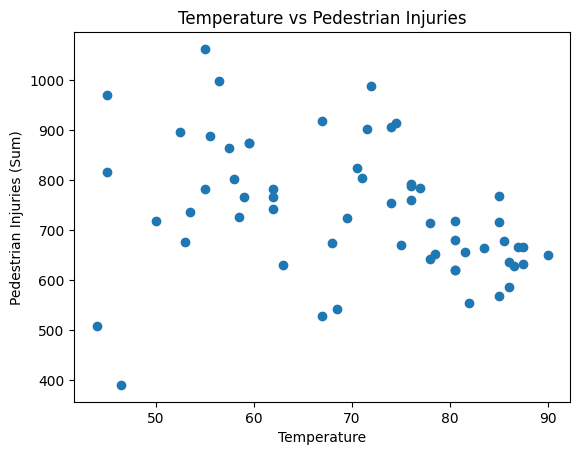

In [60]:
import matplotlib.pyplot as plt

plt.scatter(combined_data['Temperature'], combined_data['Ped_Injuries_Sum'])
plt.xlabel('Temperature')
plt.ylabel('Pedestrian Injuries (Sum)')
plt.title('Temperature vs Pedestrian Injuries')
plt.show()

# using the matplotlib to create a scatter plot so I can visualize, because the correlation number was not expected 

In [65]:
# Look at specific months
combined_data['Month'] = combined_data['YearMonth'].astype(str).str[-2:]
print(combined_data.groupby('Month')['Ped_Injuries_Sum'].mean())

# so I didn't get a very clear correlation, and instead realized that my hypothesis was wrong. it looks like winter months actually have more pedestrian injuries. October to January were the worst, but April to August were saw the least injuries.

Month
01    752.6
02    640.4
03    720.4
04    646.4
05    726.0
06    660.8
07    633.8
08    621.4
09    754.8
10    889.0
11    865.6
12    944.6
Name: Ped_Injuries_Sum, dtype: float64


In [64]:
# Months 1-12 vs pedestrian injury averages
months = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
injuries = [752.6, 640.4, 720.4, 646.4, 726.0, 660.8, 633.8, 621.4, 754.8, 889.0, 865.6, 944.6]

correlation = pd.Series(months).corr(pd.Series(injuries))
print(correlation)
# this correlation might be different than just temperature and injuries

0.6375978463103846


In [67]:
# it turns out that I probably didn't need to look at temperature at all, because that correlation was much weaker. 

# A 0.64 correlation between months and average pedestrian injuries means that as the months progress, injuries generally also increase

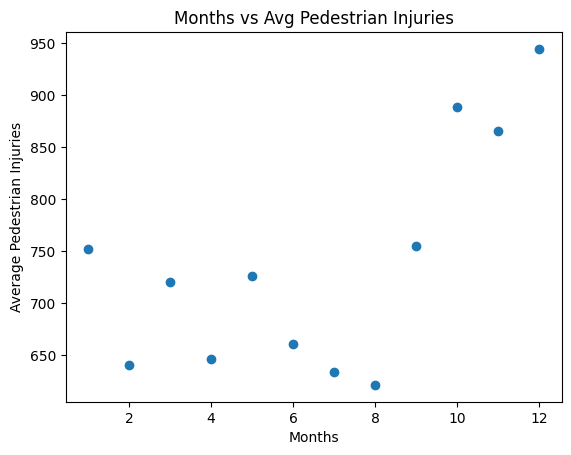

In [68]:
plt.scatter(months, injuries)
plt.xlabel('Months')
plt.ylabel('Average Pedestrian Injuries')
plt.title('Months vs Avg Pedestrian Injuries')
plt.show()